In [2]:
import numpy as np 
import jax 
import jax.numpy as jnp
import matplotlib.pyplot as plt

from projects.trial_to_trial_variability.spec import load_and_process_data

In [3]:
# read the param values from the config yaml 
import yaml
with open('projects/trial_to_trial_variability/config.yaml', 'r') as f:
    config = yaml.safe_load(f)['data_processing_params']

data = load_and_process_data(**config)

Filtering for orientation selectivity. Kept 2974 out of 20616 cells.


In [ ]:
X = data[0]
Y = data[1]

X_stim = X['stimulus']
X_train = X['train']
X_test = X['test']

Y_stim = Y['stimulus']
Y_train = Y['train']
Y_test = Y['test']

In [ ]:
import optax 
from jax.flatten_util import ravel_pytree

def neuron_model(theta,
                theta_pref_1=0.0,
                baseline=0.0,
                amplitude_1=1.0,
                width_ccw_1=1.0,
                width_cw_1=1.0,
                exponent_1=2.0,
                theta_pref_2=jnp.pi,
                amplitude_2=0.0,
                width_ccw_2=1.0,
                width_cw_2=1.0,
                exponent_2=2.0):

    min_width = 5e-2
    eps = 1e-12
    min_exponent, max_exponent = 0.1, 5.0
    width_ccw_1, width_cw_1 = jnp.clip(width_ccw_1, min_width, None), jnp.clip(width_cw_1, min_width, None)
    width_ccw_2, width_cw_2 = jnp.clip(width_ccw_2, min_width, None), jnp.clip(width_cw_2, min_width, None)
    exponent_1, exponent_2 = jnp.clip(exponent_1, min_exponent, max_exponent), jnp.clip(exponent_2, min_exponent, max_exponent)
    baseline = jnp.clip(baseline, 0.0, None)
    amplitude_1, amplitude_2 = jnp.clip(amplitude_1, 0.0, None), jnp.clip(amplitude_2, 0.0, None)

    def _signed_circ_diff_rad(angle_radians, preferred_angle_radians):
        delta = angle_radians - preferred_angle_radians
        return jnp.arctan2(jnp.sin(delta), jnp.cos(delta))
        
    signed_diff_1 = _signed_circ_diff_rad(theta, theta_pref_1) + eps  # Add small epsilon to avoid log(0) issues
    width_1_effective = jnp.where(signed_diff_1 < 0, width_ccw_1, width_cw_1)
    width_1_effective = jnp.maximum(width_1_effective, 1e-6)
    peak1_component = amplitude_1 * jnp.exp(-0.5 * (jnp.abs(signed_diff_1) / width_1_effective) ** exponent_1)

    signed_diff_2 = _signed_circ_diff_rad(theta, theta_pref_2) + eps  # Add small epsilon to avoid log(0) issues
    width_2_effective = jnp.where(signed_diff_2 < 0, width_ccw_2, width_cw_2)
    width_2_effective = jnp.maximum(width_2_effective, 1e-6)
    peak2_component = amplitude_2 * jnp.exp(-0.5 * (jnp.abs(signed_diff_2) / width_2_effective) ** exponent_2)
    return baseline + peak1_component + peak2_component

def parameter_estimator(stimuli, spike_counts):
    """
    Estimates parameters for the neuron_model_v3 based on stimulus angles and observed spike counts.
    This estimator employs statistical principles to identify and characterize tuning curve peaks,
    including baseline, amplitude, asymmetric widths, preferred directions, and exponents for
    two potential peaks.

    Parameters are estimated directly from a smoothed firing rate curve, aiming for a simple
    yet robust initial estimation suitable for generalized Gaussian-like tuning profiles.

    Parameters:
    stimuli (np.ndarray): An array of stimulus angles in radians (0 to 2*pi).
    spike_counts (np.ndarray): An array of spike counts corresponding to each stimulus.

    Returns:
    np.ndarray: An array containing the estimated parameters in the following order:
                [theta_pref_1, baseline, amplitude_1, width_ccw_1, width_cw_1,
                exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2]
    """
    # --- Configuration Constants ---
    n_bins = 256  # Number of angular bins for tuning curve estimation
    kernel_sigma = 2.5 # Sigma for Gaussian smoothing kernel
    min_peak_amplitude = 0.5 # Min amplitude (spikes/stimulus) above baseline for a peak to be considered valid
    min_model_width = 1e-6 # Minimum allowed width for numerical stability (as per model)
    default_width_value = 1.0 # Default width for non-significant peaks or non-determinable widths
    min_exponent = 0.1 # Minimum allowed exponent value
    max_exponent = 5.0 # Maximum allowed exponent value
    default_exponent_value = 2.0 # Default exponent (Gaussian)
    min_second_peak_ratio = 0.1 # Min amplitude of secondary peak relative to primary
    min_second_peak_separation = np.pi / 4 # Min angular separation between primary and secondary peaks

    # --- 1. Binning and Smoothing ---
    # Convert stimuli to bin indices, handle wrap-around implicitly by modulo in bincount
    bin_idx = ((stimuli * n_bins) / (2 * np.pi)).astype(np.int32)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    sums = np.bincount(bin_idx, weights=spike_counts, minlength=n_bins)
    counts = np.bincount(bin_idx, minlength=n_bins)

    # Create Gaussian smoothing kernel
    kernel_radius = int(3 * kernel_sigma)
    x_kernel = np.arange(-kernel_radius, kernel_radius + 1)
    kernel = np.exp(-0.5 * (x_kernel / kernel_sigma) ** 2)
    kernel /= (np.sum(kernel) + 1e-8) # Normalize kernel

    # Pad arrays for circular convolution
    pad = len(kernel) // 2
    sums_padded = np.pad(sums, (pad, pad), mode='wrap')
    counts_padded = np.pad(counts, (pad, pad), mode='wrap')

    # Convolve to get smoothed sum of spikes and counts
    num_conv = np.convolve(sums_padded, kernel, mode='valid')
    den_conv = np.convolve(counts_padded, kernel, mode='valid')

    # Calculate smoothed tuning curve (avoid division by zero)
    tuning_curve = np.zeros_like(num_conv, dtype=float)
    valid_den_mask = den_conv > 1e-8
    tuning_curve[valid_den_mask] = num_conv[valid_den_mask] / den_conv[valid_den_mask]

    angle_step = 2 * np.pi / n_bins

    # --- 2. Baseline Estimation ---
    # Baseline cannot be negative
    baseline_est = np.maximum(0.0, np.min(tuning_curve))

    # --- Helper function for estimating peak shape parameters ---
    def _get_peak_params_simple(peak_idx_val, peak_idx, bsl, tc, n_bns, ang_step,
                                min_w, def_w, min_exp, max_exp, def_exp, min_amp_thresh):
        amp = peak_idx_val - bsl
        if amp < min_amp_thresh:
            return amp, def_w, def_w, def_exp # Return default parameters if amplitude too small

        # Find bins where tuning curve drops below half-max
        target_half_val = bsl + amp / 2.0
        half_ccw_bins, half_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if half_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_half_val:
                half_ccw_bins = k
            if half_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_half_val:
                half_cw_bins = k
            if half_ccw_bins > 0 and half_cw_bins > 0:
                break
        
        # Calculate width (v1-style, implicitly assuming Gaussian form for width parameter base)
        SQRT_2_LOG_2 = np.sqrt(2 * np.log(2)) 
        width_ccw = (half_ccw_bins * ang_step) / SQRT_2_LOG_2 if half_ccw_bins > 0 else def_w
        width_cw = (half_cw_bins * ang_step) / SQRT_2_LOG_2 if half_cw_bins > 0 else def_w
        
        # Clip widths to valid range
        width_ccw = np.clip(width_ccw, min_w, np.pi)
        width_cw = np.clip(width_cw, min_w, np.pi)

        # Find bins where tuning curve drops below quarter-max for exponent estimation
        target_qtr_val = bsl + amp / 4.0
        qtr_ccw_bins, qtr_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if qtr_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_qtr_val:
                qtr_ccw_bins = k
            if qtr_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_qtr_val:
                qtr_cw_bins = k
            if qtr_ccw_bins > 0 and qtr_cw_bins > 0:
                break
        
        # Exponent estimation (log(2) / log(dist_qtr / dist_half))
        exponent_estimates = []
        if half_ccw_bins > 0 and qtr_ccw_bins > half_ccw_bins: # Ensure ratio > 1 for valid log
            exponent_estimates.append(np.log(2) / np.log(qtr_ccw_bins / half_ccw_bins))
        if half_cw_bins > 0 and qtr_cw_bins > half_cw_bins:
            exponent_estimates.append(np.log(2) / np.log(qtr_cw_bins / half_cw_bins))
        
        # Take mean of valid estimates, else default
        exponent = np.mean(exponent_estimates) if exponent_estimates else def_exp
        exponent = np.clip(exponent, min_exp, max_exp)
        
        return amp, width_ccw, width_cw, exponent

    # --- 3. Peak Identification and Parameter Estimation ---
    # Find all local maxima in the smoothed tuning curve
    local_maxima = []
    for i in range(n_bins):
        prev_val = tuning_curve[(i - 1 + n_bins) % n_bins]
        next_val = tuning_curve[(i + 1) % n_bins]
        if tuning_curve[i] >= prev_val and tuning_curve[i] >= next_val:
            local_maxima.append((tuning_curve[i], i))
    local_maxima.sort(key=lambda x: x[0], reverse=True) # Sort by peak amplitude (descending)

    # Initialize all output parameters with model defaults (if no peak is found)
    theta_pref_1 = 0.0
    amplitude_1 = default_width_value # amplitude for primary peak default to 1 for non-zero contribution if peak is small
    width_ccw_1, width_cw_1, exponent_1 = default_width_value, default_width_value, default_exponent_value
    
    theta_pref_2 = np.pi # Antipodal to default theta_pref_1
    amplitude_2 = 0.0 # Default no second peak
    width_ccw_2, width_cw_2, exponent_2 = default_width_value, default_width_value, default_exponent_value

    # Process Primary Peak
    if local_maxima:
        peak_1_val, peak_1_idx = local_maxima[0]
        # Estimate parameters for the primary (highest) peak
        amplitude_1, width_ccw_1, width_cw_1, exponent_1 = \
            _get_peak_params_simple(peak_1_val, peak_1_idx, baseline_est, tuning_curve, n_bins, angle_step,
                                    min_model_width, default_width_value, min_exponent, max_exponent,
                                    default_exponent_value, min_peak_amplitude)
        theta_pref_1 = peak_1_idx * angle_step
        
        # Process Secondary Peak (if a suitable candidate exists)
        if len(local_maxima) > 1:
            # Iterate through other local maxima to find a suitable secondary peak
            for i in range(1, len(local_maxima)):
                peak_2_val_candidate, peak_2_idx_candidate = local_maxima[i]
                current_amplitude_2_candidate = peak_2_val_candidate - baseline_est
                current_theta_pref_2_candidate = peak_2_idx_candidate * angle_step
                
                # Check amplitude significance relative to primary peak's estimated amplitude
                if current_amplitude_2_candidate < (amplitude_1 * min_second_peak_ratio):
                    continue # Skip if too small compared to the primary peak
                
                # Check angular separation from the *primary* peak
                # np.arctan2(sin(a-b), cos(a-b)) gives circular distance in [-pi, pi]
                peak_sep_rad = np.abs(np.arctan2(np.sin(theta_pref_1 - current_theta_pref_2_candidate),
                                                np.cos(theta_pref_1 - current_theta_pref_2_candidate)))
                if peak_sep_rad < min_second_peak_separation:
                    continue # Skip if too close to the primary peak

                # Valid secondary peak found, estimate its parameters
                amplitude_2, width_ccw_2, width_cw_2, exponent_2 = \
                    _get_peak_params_simple(peak_2_val_candidate, peak_2_idx_candidate, baseline_est, tuning_curve, n_bins, angle_step,
                                            min_model_width, default_width_value, min_exponent, max_exponent,
                                            default_exponent_value, min_peak_amplitude)
                theta_pref_2 = current_theta_pref_2_candidate
                
                # Break after finding the first suitable secondary peak (highest amplitude among remaining candidates)
                break
    
    # --- Pack and return parameters in the correct order for neuron_model_v3 ---
    return np.array([theta_pref_1, baseline_est, amplitude_1, width_ccw_1, width_cw_1,
                    exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2])

def parameter_estimator_jax(stimuli, spike_counts):
    """JAX-compatible equivalent of parameter_estimator for jnp.array inputs."""
    n_bins = 256
    kernel_sigma = 2.5
    min_peak_amplitude = 0.5
    min_model_width = 1e-6
    default_width_value = 1.0
    min_exponent = 0.1
    max_exponent = 5.0
    default_exponent_value = 2.0
    min_second_peak_ratio = 0.1
    min_second_peak_separation = jnp.pi / 4

    stimuli = jnp.asarray(stimuli)
    spike_counts = jnp.asarray(spike_counts)

    bin_idx = ((stimuli * n_bins) / (2 * jnp.pi)).astype(jnp.int32)
    bin_idx = jnp.clip(bin_idx, 0, n_bins - 1)

    sums = jnp.zeros(n_bins, dtype=spike_counts.dtype).at[bin_idx].add(spike_counts)
    counts = jnp.zeros(n_bins, dtype=spike_counts.dtype).at[bin_idx].add(1.0)

    kernel_radius = int(3 * kernel_sigma)
    x_kernel = jnp.arange(-kernel_radius, kernel_radius + 1)
    kernel = jnp.exp(-0.5 * (x_kernel / kernel_sigma) ** 2)
    kernel = kernel / (jnp.sum(kernel) + 1e-8)

    pad = kernel.shape[0] // 2
    sums_padded = jnp.concatenate([sums[-pad:], sums, sums[:pad]])
    counts_padded = jnp.concatenate([counts[-pad:], counts, counts[:pad]])

    num_conv = jnp.convolve(sums_padded, kernel, mode='valid')
    den_conv = jnp.convolve(counts_padded, kernel, mode='valid')
    tuning_curve = jnp.where(den_conv > 1e-8, num_conv / jnp.maximum(den_conv, 1e-8), 0.0)

    angle_step = 2 * jnp.pi / n_bins
    baseline_est = jnp.maximum(0.0, jnp.min(tuning_curve))

    def _get_peak_params_simple_jax(peak_idx_val, peak_idx, bsl, tc, n_bns, ang_step,
                                    min_w, def_w, min_exp, max_exp, def_exp, min_amp_thresh):
        amp = peak_idx_val - bsl
        search_offsets = jnp.arange(1, n_bns // 2 + 1)
        sentinel = n_bns + 1

        target_half_val = bsl + amp / 2.0
        ccw_half_vals = tc[(peak_idx - search_offsets + n_bns) % n_bns]
        cw_half_vals = tc[(peak_idx + search_offsets) % n_bns]
        half_ccw_bins = jnp.min(jnp.where(ccw_half_vals <= target_half_val, search_offsets, sentinel))
        half_cw_bins = jnp.min(jnp.where(cw_half_vals <= target_half_val, search_offsets, sentinel))
        half_ccw_bins = jnp.where(half_ccw_bins == sentinel, 0, half_ccw_bins)
        half_cw_bins = jnp.where(half_cw_bins == sentinel, 0, half_cw_bins)

        sqrt_2_log_2 = jnp.sqrt(2.0 * jnp.log(2.0))
        width_ccw = jnp.where(half_ccw_bins > 0,
                              (half_ccw_bins.astype(tc.dtype) * ang_step) / sqrt_2_log_2,
                              def_w)
        width_cw = jnp.where(half_cw_bins > 0,
                             (half_cw_bins.astype(tc.dtype) * ang_step) / sqrt_2_log_2,
                             def_w)
        width_ccw = jnp.clip(width_ccw, min_w, jnp.pi)
        width_cw = jnp.clip(width_cw, min_w, jnp.pi)

        target_qtr_val = bsl + amp / 4.0
        ccw_qtr_vals = tc[(peak_idx - search_offsets + n_bns) % n_bns]
        cw_qtr_vals = tc[(peak_idx + search_offsets) % n_bns]
        qtr_ccw_bins = jnp.min(jnp.where(ccw_qtr_vals <= target_qtr_val, search_offsets, sentinel))
        qtr_cw_bins = jnp.min(jnp.where(cw_qtr_vals <= target_qtr_val, search_offsets, sentinel))
        qtr_ccw_bins = jnp.where(qtr_ccw_bins == sentinel, 0, qtr_ccw_bins)
        qtr_cw_bins = jnp.where(qtr_cw_bins == sentinel, 0, qtr_cw_bins)

        valid_ccw = (half_ccw_bins > 0) & (qtr_ccw_bins > half_ccw_bins)
        valid_cw = (half_cw_bins > 0) & (qtr_cw_bins > half_cw_bins)
        ratio_ccw = jnp.where(valid_ccw,
                              qtr_ccw_bins.astype(tc.dtype) / half_ccw_bins.astype(tc.dtype),
                              2.0)
        ratio_cw = jnp.where(valid_cw,
                             qtr_cw_bins.astype(tc.dtype) / half_cw_bins.astype(tc.dtype),
                             2.0)
        exponent_ccw = jnp.log(2.0) / jnp.log(ratio_ccw)
        exponent_cw = jnp.log(2.0) / jnp.log(ratio_cw)
        exponent_sum = jnp.where(valid_ccw, exponent_ccw, 0.0) + jnp.where(valid_cw, exponent_cw, 0.0)
        exponent_count = valid_ccw.astype(tc.dtype) + valid_cw.astype(tc.dtype)
        exponent = jnp.where(exponent_count > 0, exponent_sum / exponent_count, def_exp)
        exponent = jnp.clip(exponent, min_exp, max_exp)

        use_default_shape = amp < min_amp_thresh
        width_ccw = jnp.where(use_default_shape, def_w, width_ccw)
        width_cw = jnp.where(use_default_shape, def_w, width_cw)
        exponent = jnp.where(use_default_shape, def_exp, exponent)
        return amp, width_ccw, width_cw, exponent

    prev_vals = jnp.roll(tuning_curve, 1)
    next_vals = jnp.roll(tuning_curve, -1)
    is_local_max = (tuning_curve >= prev_vals) & (tuning_curve >= next_vals)
    local_maxima_vals = jnp.where(is_local_max, tuning_curve, -jnp.inf)
    sorted_indices = jnp.argsort(local_maxima_vals)[::-1]
    sorted_values = local_maxima_vals[sorted_indices]
    has_primary = jnp.any(is_local_max)

    default_theta_pref_1 = jnp.asarray(0.0, dtype=tuning_curve.dtype)
    default_amplitude_1 = jnp.asarray(default_width_value, dtype=tuning_curve.dtype)
    default_theta_pref_2 = jnp.asarray(jnp.pi, dtype=tuning_curve.dtype)
    default_amplitude_2 = jnp.asarray(0.0, dtype=tuning_curve.dtype)
    default_width = jnp.asarray(default_width_value, dtype=tuning_curve.dtype)
    default_exponent = jnp.asarray(default_exponent_value, dtype=tuning_curve.dtype)

    peak_1_idx = sorted_indices[0]
    peak_1_val = sorted_values[0]
    amplitude_1_calc, width_ccw_1_calc, width_cw_1_calc, exponent_1_calc = _get_peak_params_simple_jax(
        peak_1_val, peak_1_idx, baseline_est, tuning_curve, n_bins, angle_step,
        min_model_width, default_width_value, min_exponent, max_exponent,
        default_exponent_value, min_peak_amplitude,
    )
    theta_pref_1_calc = peak_1_idx.astype(tuning_curve.dtype) * angle_step

    theta_pref_1 = jnp.where(has_primary, theta_pref_1_calc, default_theta_pref_1)
    amplitude_1 = jnp.where(has_primary, amplitude_1_calc, default_amplitude_1)
    width_ccw_1 = jnp.where(has_primary, width_ccw_1_calc, default_width)
    width_cw_1 = jnp.where(has_primary, width_cw_1_calc, default_width)
    exponent_1 = jnp.where(has_primary, exponent_1_calc, default_exponent)

    secondary_indices = sorted_indices[1:]
    secondary_values = sorted_values[1:]
    secondary_amplitudes = secondary_values - baseline_est
    secondary_thetas = secondary_indices.astype(tuning_curve.dtype) * angle_step
    secondary_separation = jnp.abs(jnp.arctan2(jnp.sin(theta_pref_1 - secondary_thetas),
                                              jnp.cos(theta_pref_1 - secondary_thetas)))
    valid_secondary = (
        jnp.isfinite(secondary_values)
        & (secondary_amplitudes >= (amplitude_1 * min_second_peak_ratio))
        & (secondary_separation >= min_second_peak_separation)
    )
    has_secondary = has_primary & jnp.any(valid_secondary)
    first_secondary_pos = jnp.argmax(valid_secondary.astype(jnp.int32))
    peak_2_idx = secondary_indices[first_secondary_pos]
    peak_2_val = secondary_values[first_secondary_pos]

    amplitude_2_calc, width_ccw_2_calc, width_cw_2_calc, exponent_2_calc = _get_peak_params_simple_jax(
        peak_2_val, peak_2_idx, baseline_est, tuning_curve, n_bins, angle_step,
        min_model_width, default_width_value, min_exponent, max_exponent,
        default_exponent_value, min_peak_amplitude,
    )
    theta_pref_2_calc = peak_2_idx.astype(tuning_curve.dtype) * angle_step

    theta_pref_2 = jnp.where(has_secondary, theta_pref_2_calc, default_theta_pref_2)
    amplitude_2 = jnp.where(has_secondary, amplitude_2_calc, default_amplitude_2)
    width_ccw_2 = jnp.where(has_secondary, width_ccw_2_calc, default_width)
    width_cw_2 = jnp.where(has_secondary, width_cw_2_calc, default_width)
    exponent_2 = jnp.where(has_secondary, exponent_2_calc, default_exponent)

    return jnp.array([theta_pref_1, baseline_est, amplitude_1, width_ccw_1, width_cw_1,
                      exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2])

def loss_fn(Y_pred, Y_true):
    """
    Elementwise squared-error loss.
    """
    return (Y_true - Y_pred) ** 2

# Per-sample loss function
def loss_single_sample(params, x_i, y_i):
    y_pred = neuron_model(x_i, *params)
    if y_i.ndim == 1:
        y_i = y_i[None, :]
    if y_pred.ndim == 1:
        y_pred = y_pred[None, :]
    sample_loss = jnp.asarray(loss_fn(y_pred, y_i))
    if sample_loss.ndim == 0:
        return sample_loss
    return jnp.mean(sample_loss)

def _optimize_params(params, x, y, learning_rate=1e-3, max_iter=500):
    learning_rate_local = float(learning_rate)
    opt = optax.adam(learning_rate_local, b1=0.9, b2=0.999, eps=1e-8)
    # flat_params, unflatten = ravel_pytree(params)
    opt_state = opt.init(params)

    # Vectorize over samples
    # params: pytree (batched), x: (n_samples, n_features, n_trials_x), y: (n_samples, n_targets, n_trials_y)
    # Output: (n_samples,)
    loss_total = jax.vmap(loss_single_sample, in_axes=(0, 0, 0), out_axes=0)

    print(f"DEBUG : {x.shape}, {y.shape}, {params.shape}")
    loss_param = lambda params: jnp.mean(loss_total(params, x, y))
    loss_param_and_grad = jax.value_and_grad(loss_param)

    @jax.jit
    def train_step(params, opt_state):
        loss, grad = loss_param_and_grad(params)
        updates, opt_state = opt.update(grad, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss

    print_every = 50
    initial_loss = loss_param(params)

    best_loss, best_params = initial_loss.copy(), params.copy()
    for step in range(1, max_iter + 1):
        # _check_timeout()
        params, opt_state, loss_val = train_step(params, opt_state)
        # _check_timeout()
        if jnp.isnan(loss_val) or jnp.isinf(loss_val) or jnp.any(jnp.isnan(params)) or jnp.any(jnp.isinf(params)):
            logging.info(f"Loss is NaN or Inf at step {step}. Stopping optimization.")
            print(f"Final loss: {loss_val:.4f} at step {step}")
            break
        if loss_val < best_loss:
            best_loss = loss_val.copy()
            best_params = params.copy()
        if step % print_every == 0:
            print(f"step {step:4d}  loss {loss_val:.4f}")
    # params = unflatten(best_params)
    print(f"params optimized. Loss: {best_loss:.4f}")
    return best_params

stimuli = jnp.array(X_stim) # shape (n_source, n_time)
source_train = jnp.array(X_train) # shape (n_source, n_time)
target_train = jnp.array(Y_train) # shape (n_target, n_time)

# Calculate the initial parameters for all source cells 
source_params_init = jax.vmap(parameter_estimator_jax)(stimuli, source_train) # shape (n_source, n_params)
# use gradient descent to optimise the parameters 

source_params = _optimize_params(source_params_init, stimuli, source_train) 

target_params_init = jax.vmap(parameter_estimator_jax)(stimuli, target_train) # shape (n_target, n_params)
target_params = _optimize_params(target_params_init, stimuli, target_train) 


DEBUG : (743, 4282), (743, 4282), (743, 11)
step   50  loss 0.6716
step  100  loss 0.6686
step  150  loss 0.6668
step  200  loss 0.6656
step  250  loss 0.6647
step  300  loss 0.6641
step  350  loss 0.6636
step  400  loss 0.6633
step  450  loss 0.6630
step  500  loss 0.6628
params optimized. Loss: 0.6628
DEBUG : (743, 4282), (743, 4282), (743, 11)
step   50  loss 0.6658
step  100  loss 0.6624
step  150  loss 0.6603
step  200  loss 0.6587
step  250  loss 0.6576
step  300  loss 0.6568
step  350  loss 0.6563
step  400  loss 0.6558
step  450  loss 0.6555
step  500  loss 0.6553
params optimized. Loss: 0.6553


In [14]:
def model_v1(X, params):
    """ Gain Modulation + per cell modulation

    Equation : For each target cell c at timepoint t with stimulus angle theta, 
        f(theta, t; cell_params) = a(t) * g(theta(t) ; cell_params) + b(t) * c
    where g(theta(t); cell_params) is some tuning function. 

    Args : 
        X (dict) : Inputs object with keys 'stimulus', 'train', 'test'. Each with shape (n_source_cells, n_time)
        params (dict) : Parameter dictionary with keys: 
            - source_tuning_params : parameters for the tuning function g(theta) (shape (n_source_cells, n_params))
            - target_tuning_params : parameters for the tuning function g(theta) (shape (n_target_cells, n_params))
            - target_cell_modulation : c (shape (n_target_cells,)) # this parameter will be fit using gradient descent

    Returns : 
        jnp.ndarray : Predicted responses for the target cells with shape (n_target_cells, n_time)
    """
    stimuli = jnp.array(X['stimulus']) # shape (n_source, n_time)
    source_train = jnp.array(X['response']) # shape (n_source, n_time)

    # Step 1 : For every source cell, fit a peaky tuning curve 
    # Step 2 : Use ALS (Alternating Least Squares) to fit a(t), b(t), and g(theta) iteratively.

    source_tuning_params = params['source_tuning_params'] # shape (n_source_cells, n_params)
    target_tuning_params = params['target_tuning_params'] # shape (n_target_cells, n_params)
    
    # Calculate the predicted response for each source cell based on the optimised parameters and stimulus 
    # g_source = neuron_model_batched(stim_1d, source_tuning_params) # shape (n_source, n_time)
    g_source = jax.vmap(lambda stim, params: neuron_model(stim, *params), in_axes=(0, 0))(stimuli, source_tuning_params) # shape (n_source, n_time)
    g_source = g_source.T # shape (n_time, n_source)  

    n_t, n_source = g_source.shape

    # Use ALS to fit a(t) and b(t) given g_source and the target responses.
    a = jnp.ones(n_t) # shape (n_time,)
    b = jnp.zeros(n_t) # shape (n_time,)
    prev_err = np.inf

    # initial guess for per cell modulation
    c = jnp.ones(n_source) # shape (n_source,)

    max_iter = 10
    tol = 1e-2
    Y = source_train.T # shape (n_time, n_source)
    for i in range(max_iter):
        # -- Step A : Solve for a(t) and b(t) -- (fix c)
        print(f"Iteration {i}")
        for t in range(n_t):
            X_linalg = jnp.stack([g_source[t, :], c], axis=1) # shape (n_source, 2)
            # Solve Y_t = X * [a_t, b_t].T 
            coefs, _, _, _ = jnp.linalg.lstsq(X_linalg, Y[t, :], rcond=None)
            a = a.at[t].set(coefs[0])
            b = b.at[t].set(coefs[1])

        # Step B ; Solve for c (fix a(t) and b(t))
        # a has shape (n_time,), b has shape (n_time,), g_source has shape (n_time, n_source), Y has shape (n_time, n_source)
        residual = Y - (a[:, None] * g_source) # has shape (n_time, n_source)
        c = (residual.T @ b) / (b @ b)

        # Step C : Normalisation 
        # Normalise c to unit length to keep the scale stable
        norm_val = jnp.linalg.norm(c)
        c /= norm_val
        b *= norm_val

        current_fit = a[:, None] * g_source + b[:, None] * c[None, :]
        err = np.linalg.norm(Y - current_fit)

        if abs(prev_err - err) < tol:
            print(f"ALS converged at iteration {i}. Error: {err:.4f}")
            break
        prev_err = err
    
    # calculate c of target cells using the optimised a(t) and b(t) and the target responses
    g_target = jax.vmap(lambda stim, params: neuron_model(stim, *params), in_axes=(0, 0))(stimuli, target_tuning_params).T # shape (n_time, n_target)
    pred = a[:, None] * g_target + b[:, None] * c[None, :]
    return pred.T, a, b, c # shape (n_target, n_time)


In [8]:
params = {"source_tuning_params": source_params, "target_tuning_params": target_params, "target_cell_modulation": jnp.ones(source_params.shape[0])}
Y_pred_train, a, b, c = model_v1(X, params)

Iteration 0
Iteration 1
Iteration 2
ALS converged at iteration 2. Error: 1319.0922


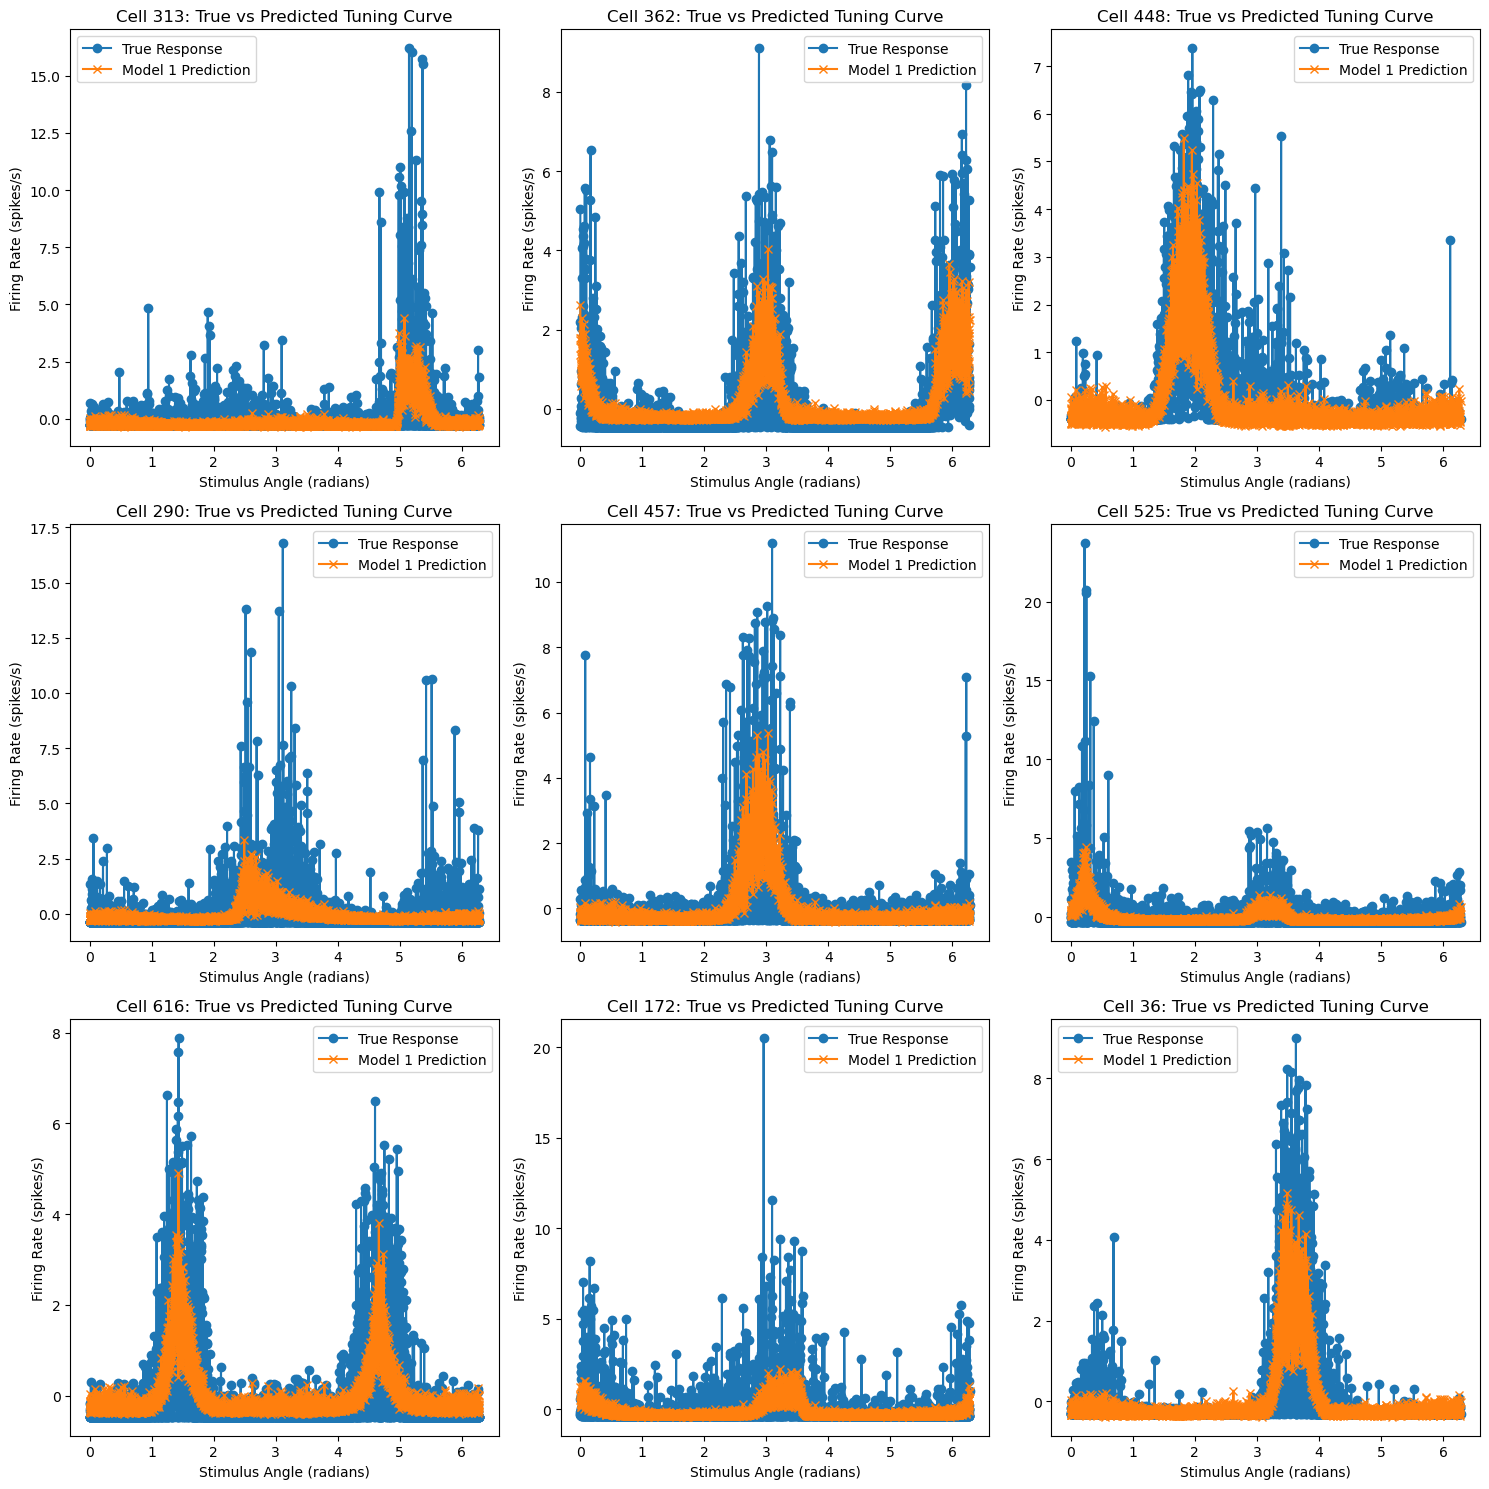

In [9]:
def plot_model_fit(Y_real, Y_pred, cell_idxs, Y_another_pred=None):
    n_cells = len(cell_idxs)
    plt.figure(figsize=(15, 15))
    for i, cell_idx in enumerate(cell_idxs):
        plt.subplot(3, 3, i + 1)
        y_true = Y_real[cell_idx, :]
        y_pred = Y_pred[cell_idx, :]
        angles = Y['stimulus'][0]
        order = np.argsort(angles)
        angles = angles[order]
        y_true = y_true[order]
        y_pred = y_pred[order]
        plt.plot(angles, y_true.flatten(), label='True Response', marker='o')
        plt.plot(angles, y_pred.flatten(), label='Model 1 Prediction', marker='x')

        if Y_another_pred is not None:
            y_another_pred = Y_another_pred[cell_idx, :]
            y_another_pred = y_another_pred[order]
            plt.plot(angles, y_another_pred.flatten(), label='Model 2 Prediction', marker='s')

        plt.xlabel('Stimulus Angle (radians)')
        plt.ylabel('Firing Rate (spikes/s)')
        plt.title(f'Cell {cell_idx}: True vs Predicted Tuning Curve')
        plt.legend()
        
    plt.tight_layout()
    plt.show()

cell_idxs = np.random.choice(Y_train.shape[0], 9)
plot_model_fit(Y_train, Y_pred_train, cell_idxs)

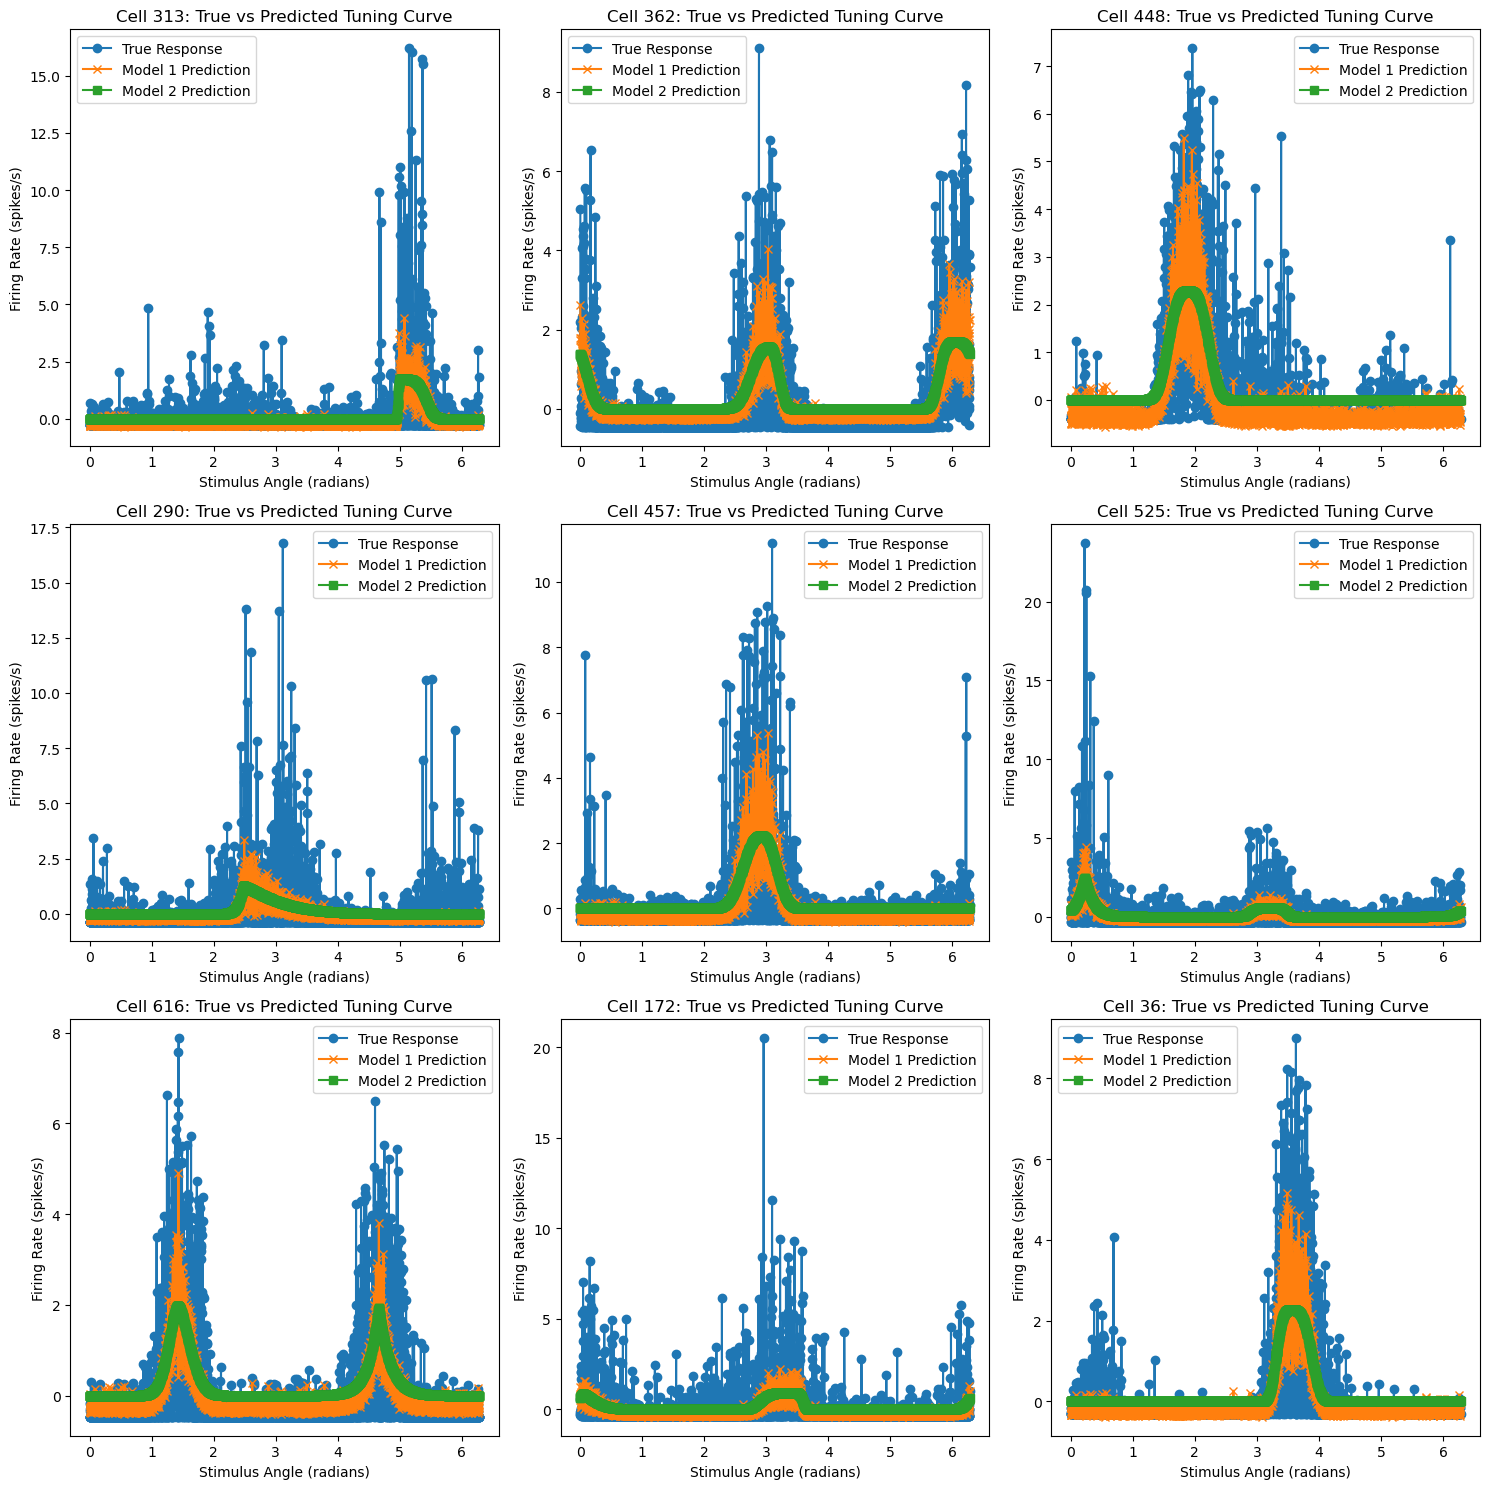

In [17]:
def model_simple(X, params):
    """ Just the default peaky tuning curve

    Equation : For each target cell c at timepoint t with stimulus angle theta, 
        f(theta, t; cell_params) = g(theta(t)
    where g(theta(t); cell_params) is the peaky tuning function. 

    Args : 
        X (dict) : Inputs object with keys 'stimulus', 'train', 'test'. Each with shape (n_source_cells, n_time)
        params (dict) : Parameter dictionary with keys: 
            - source_tuning_params : parameters for the tuning function g(theta) (shape (n_source_cells, n_params))
            - target_tuning_params : parameters for the tuning function g(theta) (shape (n_target_cells, n_params))
            - target_cell_modulation : c (shape (n_target_cells,)) # this parameter will be fit using gradient descent

    Returns : 
        jnp.ndarray : Predicted responses for the target cells with shape (n_target_cells, n_time)
    """
    stimuli = jnp.array(X['stimulus']) # shape (n_source, n_time)
    source_train = jnp.array(X['response']) # shape (n_source, n_time)

    target_tuning_params = params['target_tuning_params'] # shape (n_target_cells, n_params)
    
    g_target = jax.vmap(lambda stim, params: neuron_model(stim, *params), in_axes=(0, 0))(stimuli, target_tuning_params).T # shape (n_time, n_target)    
    return g_target.T

X_simple = {"stimulus": X['stimulus'], "response": X_train}
Y_pred_train_simple = model_simple(X_simple, params)

plot_model_fit(Y_train, Y_pred_train, cell_idxs, Y_another_pred=Y_pred_train_simple)


In [11]:
# compare the r^2 of the two models
def r_squared(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_v1 = r_squared(Y_train, Y_pred_train)
r2_simple = r_squared(Y_train, Y_pred_train_simple)

print(f"R^2 for model_v1: {r2_v1:.4f}")
print(f"R^2 for model_simple: {r2_simple:.4f}")

R^2 for model_v1: 0.4467
R^2 for model_simple: 0.3447


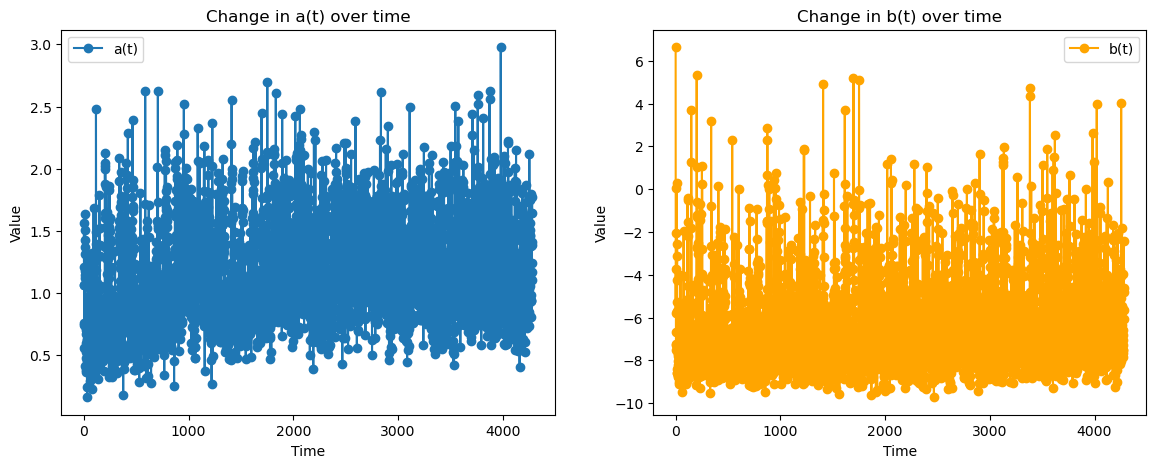

In [12]:
# plot the change in a, b over time
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(a, label='a(t)', marker='o')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Change in a(t) over time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(b, label='b(t)', marker='o', color='orange')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Change in b(t) over time')
plt.legend()

plt.show()

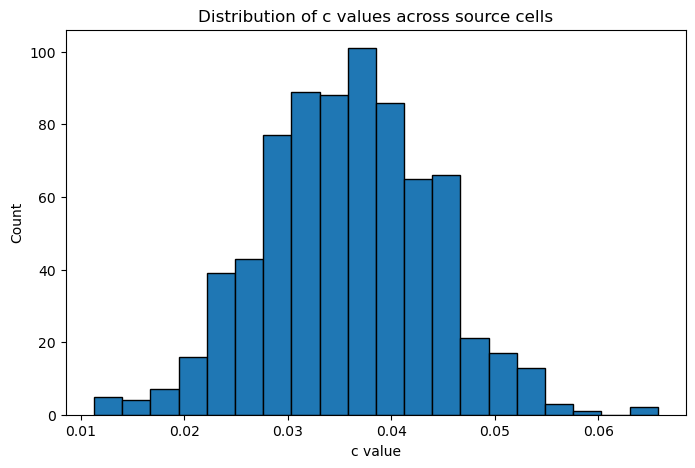

In [13]:
# plot the distribution of c 
plt.figure(figsize=(8, 5))
plt.hist(c, bins=20, edgecolor='k')
plt.xlabel('c value')
plt.ylabel('Count')
plt.title('Distribution of c values across source cells')
plt.show()

In [ ]:
# I can Maybe fit the peakiness parameters from the training trials alone, and then I use those parameters to compare the prediction against the test trials 

X_test_input = {"stimulus": X['stimulus'], "response": X_test}

params = {"source_tuning_params": source_params, "target_tuning_params": target_params, "target_cell_modulation": jnp.ones(source_params.shape[0])}
Y_pred_test, a, b, c = model_v1(X_test_input, params)


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
ALS converged at iteration 7. Error: 1695.0332


KeyError: 'train'

In [18]:
Y_pred_test_simple = model_simple(X_test_input, params)

R^2 for model_v1: -0.0524
R^2 for model_simple: 0.3447


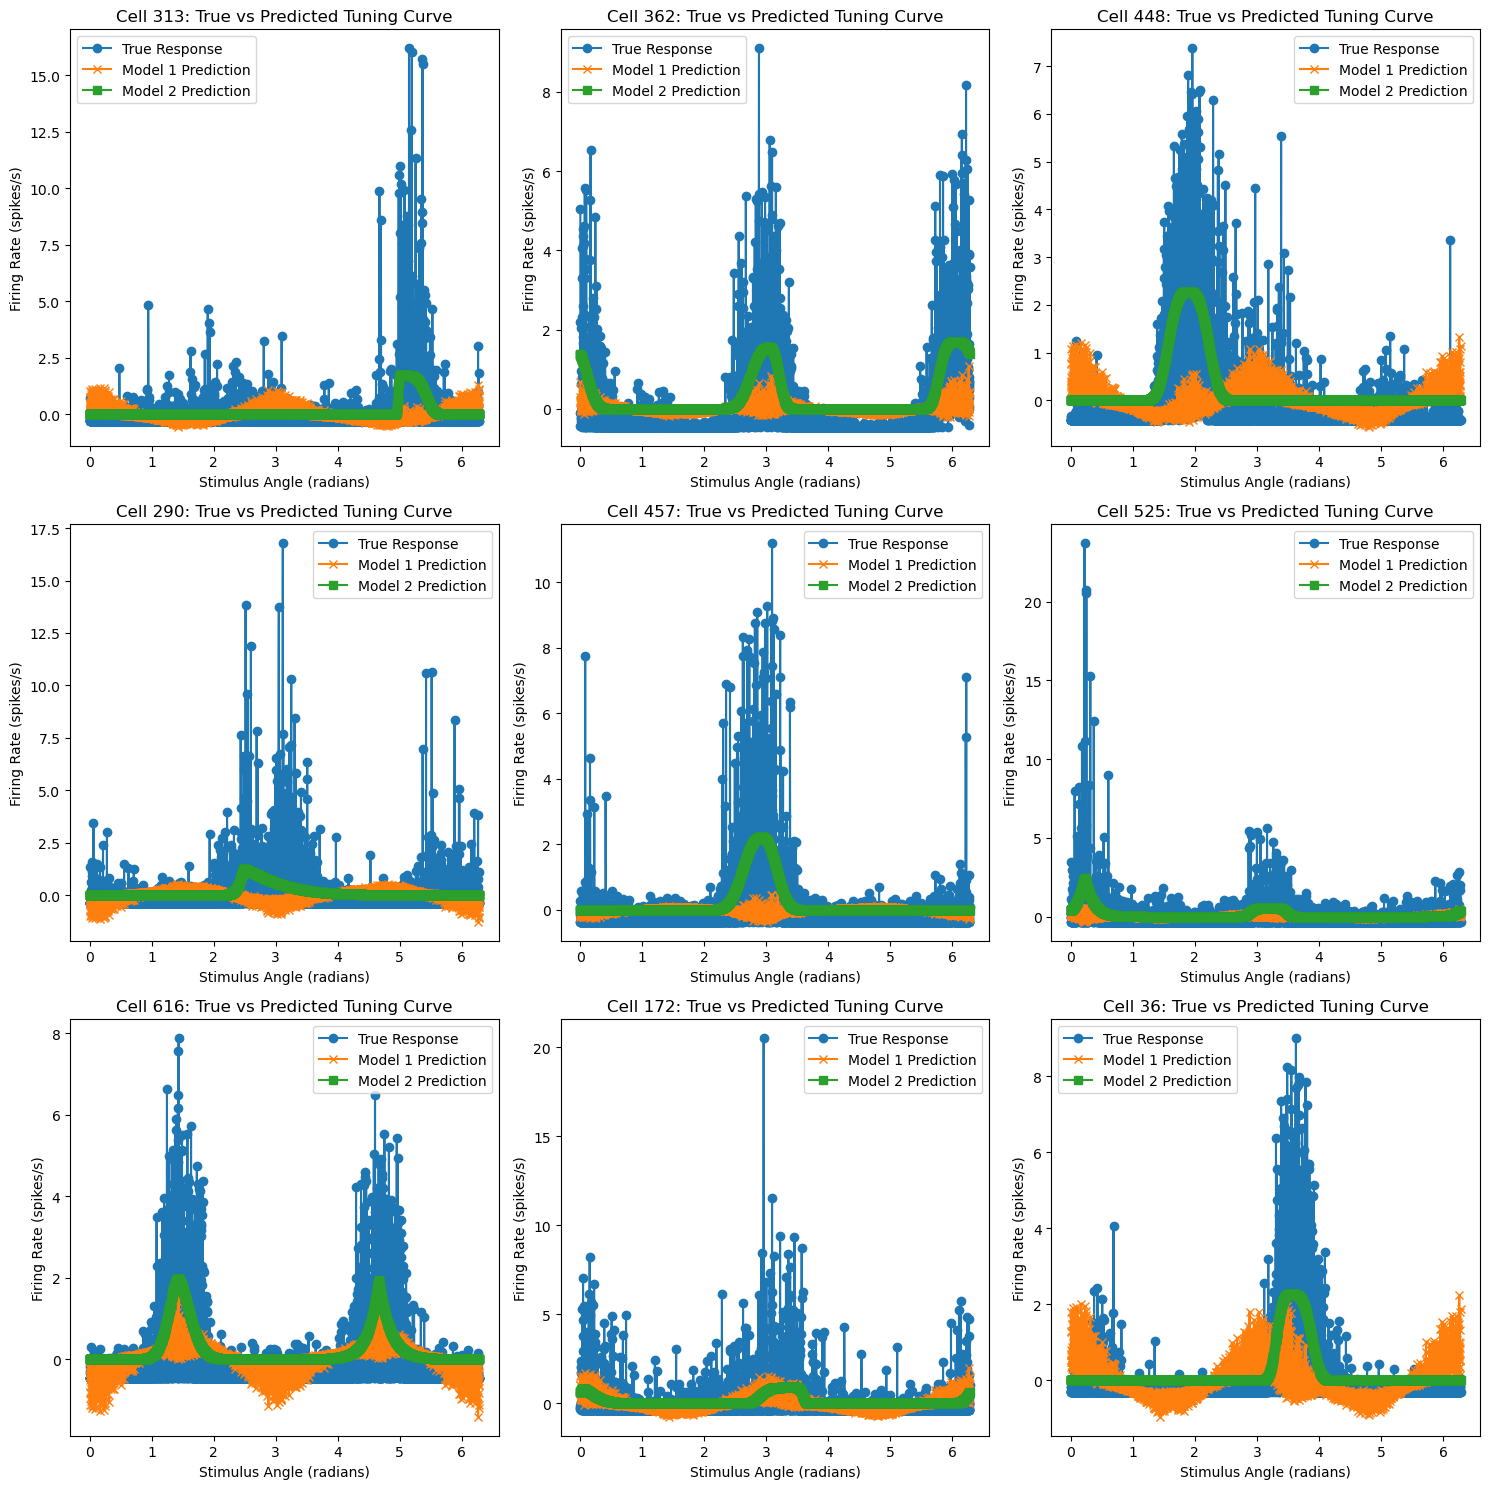

In [19]:
r2_v1_test = r_squared(Y_train, Y_pred_test)
r2_simple_test = r_squared(Y_train, Y_pred_test_simple)

print(f"R^2 for model_v1: {r2_v1_test:.4f}")
print(f"R^2 for model_simple: {r2_simple_test:.4f}")

plot_model_fit(Y_train, Y_pred_test, cell_idxs, Y_another_pred=Y_pred_test_simple)